In [3]:
#!pip install yfinance

In [4]:
#Define libreries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

In [5]:
#Define tickers which we want to analize
tickers = ["AAPL", "MSFT", "AMZN"]
data = yf.download(tickers, start="2020-01-01", end="2021-01-01")["Close"].dropna()

[*********************100%***********************]  3 of 3 completed


In [7]:
data.head()

Ticker,AAPL,AMZN,MSFT
Date,,,
2020-01-02,72.400528,94.900497,152.505692
2020-01-03,71.696632,93.748497,150.606766
2020-01-06,72.267921,95.143997,150.996033
2020-01-07,71.928047,95.343002,149.619263
2020-01-08,73.085098,94.598503,152.002457


In [8]:
#Save retunrs
returns = np.log(data / data.shift(1)).dropna()
returns

Ticker,AAPL,AMZN,MSFT
Date,,,
2020-01-03,-0.009770,-0.012213,-0.012530
2020-01-06,0.007937,0.014776,0.002581
2020-01-07,-0.004714,0.002089,-0.009160
2020-01-08,0.015958,-0.007839,0.015803
2020-01-09,0.021018,0.004788,0.012416
...,...,...,...
2020-12-24,0.007683,-0.003957,0.007797
2020-12-28,0.035141,0.034470,0.009872
2020-12-29,-0.013404,0.011517,-0.003607


In [10]:
#Calculate the Expected return
Expeted_returns = returns.mean()
Expeted_returns

Ticker
AAPL    0.002293
AMZN    0.002143
MSFT    0.001334
dtype: float64

In [11]:
# Calculate the difference between each return and its expected return
differences = returns - Expeted_returns

# Square these differences to get 'desv_esp' as a DataFrame
desv_esp = differences.pow(2)

print("DataFrame 'desv_esp' (Squared Deviations):")
display(desv_esp.head())

# To get the variance for each ticker, sum the squared deviations and divide by (N-1)
# N is the number of observations
N = len(returns)
variance = desv_esp.sum() / (N - 1)

print("\nVariance (for each ticker):")
display(variance)

# The standard deviation is the square root of the variance, which is the volatility
volatility = np.sqrt(variance)

print("\nVolatilidad Promedio (Standard Deviation for each ticker):")
display(volatility)

DataFrame 'desv_esp' (Squared Deviations):


Ticker,AAPL,AMZN,MSFT
Date,,,
2020-01-03,0.000146,2.060973e-04,0.000192
2020-01-06,0.000032,1.595951e-04,0.000002
2020-01-07,0.000049,2.844950e-09,0.000110
2020-01-08,0.000187,9.964155e-05,0.000209
2020-01-09,0.000351,6.995609e-06,0.000123



Variance (for each ticker):


Ticker
AAPL    0.000866
AMZN    0.000586
MSFT    0.000770
dtype: float64


Volatilidad Promedio (Standard Deviation for each ticker):


Ticker
AAPL    0.029434
AMZN    0.024198
MSFT    0.027746
dtype: float64

In [13]:
#Matriz de covarianza: mide cómo se mueven las acciones entre sí (si tienden a subir/bajar juntas o de forma independiente).
covariance_matrix = returns.cov()
print("Matriz de covarianza:")
display(covariance_matrix)

Matriz de covarianza:


Ticker,AAPL,AMZN,MSFT
Ticker,,,
AAPL,0.000866,0.000501,0.000689
AMZN,0.000501,0.000586,0.000498
MSFT,0.000689,0.000498,0.000770


In [28]:
#En este caso, se va a tener en cuenta cuanto se tiene de dinero
capital = 100000
num_process = 1000

In [15]:
first_price = data.iloc[0]
first_price

Ticker
AAPL     72.400528
AMZN     94.900497
MSFT    152.505692
Name: 2020-01-02 00:00:00, dtype: float64

In [27]:
#Se calcula la varianza del portafolio
var_mat_portfolio = 0
for i in range(len(tickers)):
  for j in range(len(tickers)):
    #print(f"I = {i}")
    var_mat_portfolio += weigth[i] * weigth[j] * covariance_matrix[tickers[i]][tickers[j]]
    #print(f"weight = {weigth[i]}")
    #print(covariance_matrix[tickers[i]][tickers[0]])
var_mat_portfolio

np.float64(0.0006116322177710235)

In [29]:
expected_returns_list = []
portfolio_variances_list = []
weigth_list = []

# Initialize model_Markowitz as an empty dictionary
model_Markowitz = {}


for k in range(num_process):
  print(f"Vamos en el paso:{k}")
  raw_weights = np.round(np.random.random(len(tickers)), 2)

  # Normalize them so their sum is 1
  weigth = raw_weights / raw_weights.sum()


  count = 0  
  while abs(1 - ((weigth * first_price ).sum() / 100)) > 0.001 and count < 100  :
    raw_weights = np.round(np.random.random(len(tickers)), 2)
    weigth = np.round(raw_weights / raw_weights.sum(), 2)
    count += 1
        

  weigth_list.append(weigth) # Moved here: Append the final valid weights for this iteration

  portfolio_expected_return = (Expeted_returns * weigth).sum()
  expected_returns_list.append(portfolio_expected_return)

  var_port_k = 0 # Initialize for each portfolio
  for i in range(len(tickers)):
    for j in range(len(tickers)):
      var_port_k += weigth[i] * weigth[j] * covariance_matrix[tickers[i]][tickers[j]] # Corrected: Accumulate the sum
  portfolio_variances_list.append(var_port_k)


model_Markowitz['portfolio_returns'] = expected_returns_list
model_Markowitz['portfolio_variances'] = portfolio_variances_list

Vamos en el paso:0
Vamos en el paso:1
Vamos en el paso:2
Vamos en el paso:3
Vamos en el paso:4
Vamos en el paso:5
Vamos en el paso:6
Vamos en el paso:7
Vamos en el paso:8
Vamos en el paso:9
Vamos en el paso:10
Vamos en el paso:11
Vamos en el paso:12
Vamos en el paso:13
Vamos en el paso:14
Vamos en el paso:15
Vamos en el paso:16
Vamos en el paso:17
Vamos en el paso:18
Vamos en el paso:19
Vamos en el paso:20
Vamos en el paso:21
Vamos en el paso:22
Vamos en el paso:23
Vamos en el paso:24
Vamos en el paso:25
Vamos en el paso:26
Vamos en el paso:27
Vamos en el paso:28
Vamos en el paso:29
Vamos en el paso:30
Vamos en el paso:31
Vamos en el paso:32
Vamos en el paso:33
Vamos en el paso:34
Vamos en el paso:35
Vamos en el paso:36
Vamos en el paso:37
Vamos en el paso:38
Vamos en el paso:39
Vamos en el paso:40
Vamos en el paso:41
Vamos en el paso:42
Vamos en el paso:43
Vamos en el paso:44
Vamos en el paso:45
Vamos en el paso:46
Vamos en el paso:47
Vamos en el paso:48
Vamos en el paso:49
Vamos en e

In [30]:
model_Markowitz['sharpe_ratio'] = np.array(model_Markowitz['portfolio_returns']) / np.sqrt(np.array(model_Markowitz['portfolio_variances']))

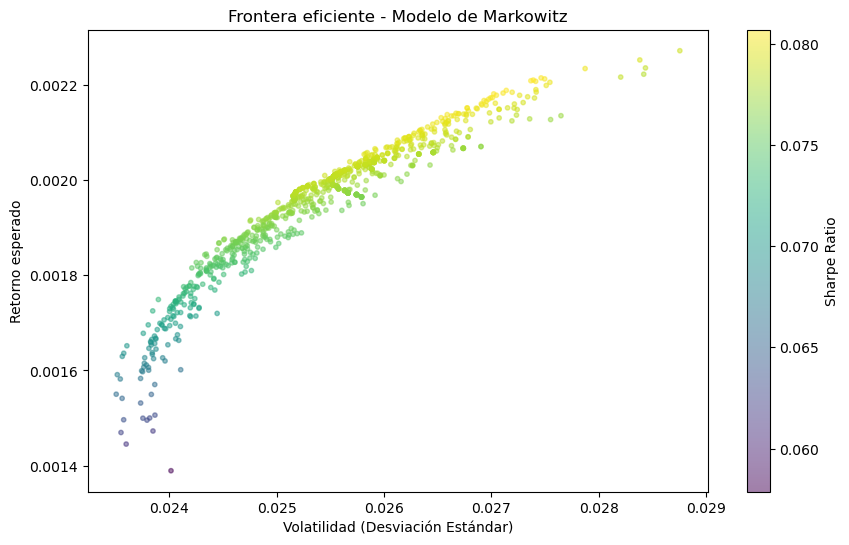

In [31]:
plt.figure(figsize=(10,6))
plt.scatter(np.sqrt(model_Markowitz['portfolio_variances']),
            model_Markowitz['portfolio_returns'],
            c=model_Markowitz['sharpe_ratio'],
            cmap="viridis",
            s=10, alpha=0.5)

plt.xlabel("Volatilidad (Desviación Estándar)")
plt.ylabel("Retorno esperado")
plt.title("Frontera eficiente - Modelo de Markowitz")
plt.colorbar(label="Sharpe Ratio")
plt.show()

In [32]:
model_Markowitz_df = pd.DataFrame(model_Markowitz)

# Find the portfolio with the minimum variance
min_variance_portfolio = model_Markowitz_df.loc[model_Markowitz_df['portfolio_variances'].idxmin()]
display(min_variance_portfolio)

portfolio_returns      0.001550
portfolio_variances    0.000552
sharpe_ratio           0.065955
Name: 948, dtype: float64

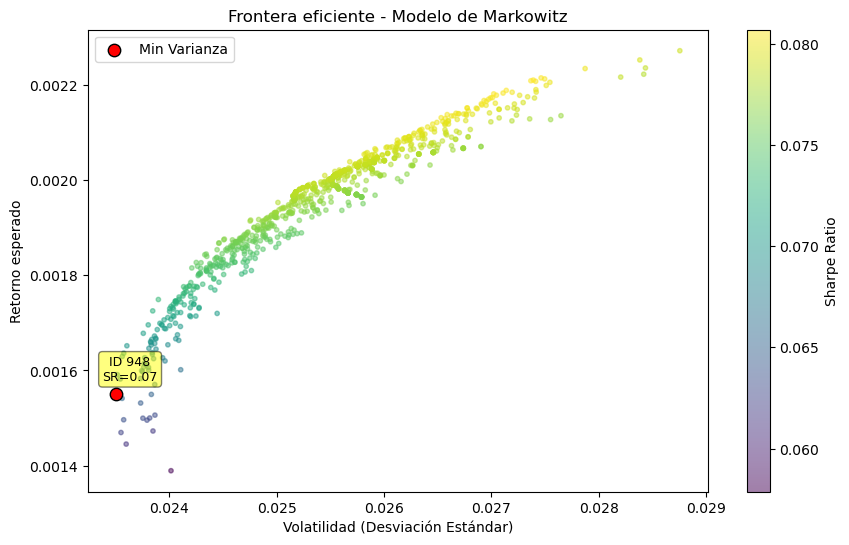

In [33]:
plt.figure(figsize=(10,6))
plt.scatter(np.sqrt(model_Markowitz['portfolio_variances']),
            model_Markowitz['portfolio_returns'],
            c=model_Markowitz['sharpe_ratio'],
            cmap="viridis",
            s=10, alpha=0.5)

plt.xlabel("Volatilidad (Desviación Estándar)")
plt.ylabel("Retorno esperado")
plt.title("Frontera eficiente - Modelo de Markowitz")
plt.colorbar(label="Sharpe Ratio")

# --- Punto 1: Máximo Sharpe ---
idx_min = model_Markowitz_df['portfolio_variances'].idxmin()
x_sharpe = np.sqrt(model_Markowitz_df['portfolio_variances'][idx_min])
y_sharpe = model_Markowitz_df['portfolio_returns'][idx_min]

plt.scatter(x_sharpe, y_sharpe, color='red', s=80, edgecolor='black', label="Min Varianza")
plt.annotate(f"ID {idx_min}\nSR={model_Markowitz_df['sharpe_ratio'][idx_min]:.2f}",
             (x_sharpe, y_sharpe),
             textcoords="offset points", xytext=(10,10), ha='center',
             fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))


plt.legend()
plt.show()


In [34]:
weights_series = pd.Series(weigth_list[idx_min], index=first_price.index)
num_acciones_float = weights_series * capital / first_price
num_acciones = num_acciones_float.astype(int)
num_acciones

Ticker
AAPL    179
AMZN    136
MSFT    478
dtype: int64

In [35]:
print(f"Los pesos de las acciones son: {weigth_list[idx_min]}")
print(f"La ganancia esperada anual es: {((1 + Expeted_returns)** 252 - 1 ) }")
print(f"La ganancia esperada anual por accion es: {((1 + Expeted_returns)** 252 - 1 ) * num_acciones}")

Los pesos de las acciones son: [0.13 0.13 0.73]
La ganancia esperada anual es: Ticker
AAPL    0.781220
AMZN    0.714980
MSFT    0.399115
dtype: float64
La ganancia esperada anual por accion es: Ticker
AAPL    139.838437
AMZN     97.237269
MSFT    190.777158
dtype: float64
